0. Imports and constants

In [8]:
import numpy as np
from numpy.fft import fft2, fftshift
from matplotlib import pyplot as plt

HORIZ_RES = 1024
VERT_RES = 1024

HORIZ_SIZE = 30 # mm
VERT_SIZE = 30 # mm

V_s = 343 * 1000 # mm/s

1. Define analysis behavior

In [9]:
w = np.ones(16)

freqs = [2e3, 1e4, 2e4]

2. Define array grid

In [10]:
# for now we're just going to use a 4x4 grid

mic_pos = []
for i in range(4):
    for j in range(4):
        mic_pos.append([i * 8.0 - 12.0 + HORIZ_SIZE / 2, j * 8.0 - 12.0 + VERT_SIZE / 2])

assert len(mic_pos) == len(w)

3. Fourier analysis

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (1024,) + inhomogeneous part.

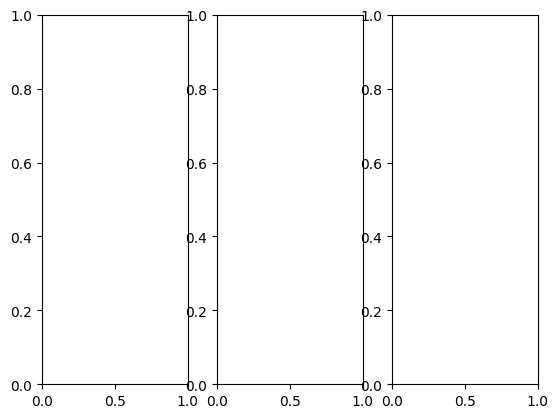

In [ ]:
grid = np.zeros((HORIZ_RES, VERT_RES))

for w_n, m_n in zip(w, mic_pos):
    grid_pos = [int(m_n[0] * HORIZ_RES / HORIZ_SIZE), int(m_n[1] * VERT_RES / VERT_SIZE)]
    grid[grid_pos[0], grid_pos[1]] = w_n

X = fftshift(fft2(grid))

fig, axs = plt.subplots(1, len(freqs))

for n, f in enumerate(freqs):

    k = f * 2 * np.pi / V_s
    
    p = []

    angs_x = []
    angs_y = []

    for n_y, i in enumerate(X):
        angs_x.append([])
        angs_y.append([])
        p.append([])

        k_y = 2 * np.pi * (n_y - VERT_SIZE / 2) / VERT_SIZE
        for n_x, j in enumerate(i):
            
            k_x = 2 * np.pi * (n_x - HORIZ_SIZE / 2) / HORIZ_SIZE

            temp = k**2 - k_x**2 - k_y**2
            if temp >= 0:
                k_z = np.sqrt(temp)
                theta_x = np.atan2(k_z, k_x)
                theta_y = np.atan2(k_z, k_y)

                p[-1].append(np.abs(X[n_y, n_x]))
                angs_x[-1].append(theta_x)
                angs_y[-1].append(theta_y)

    pmax = np.max(p)
    p = np.divide(p, pmax)

    ax = axs[n]
    shading = ax.pcolormesh(theta_x, theta_y, p, cmap="inferno", shading="auto")
    ax.set_title(f"Angular response, $f={f}$ Hz")
    ax.set_xlabel("$\\theta_x$")
    ax.set_ylabel("$\\theta_y$")

    fig.colorbar(shading, ax=ax, label="Relative intensity")

plt.tight_layout()
plt.show()
